# **Imports & Libraries**

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
import numpy as np
import librosa
import librosa.display
import IPython.display as ipd
import torch.nn.functional as F
import matplotlib.pyplot as plt
import json
import timm
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
from IPython.display import Audio
from tqdm import tqdm
import math
from sympy import prod
import math

from torch.nn import functional as F
import einops
from einops import rearrange
from torch.nn.utils.parametrizations import weight_norm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
train_csv = pd.read_csv('/kaggle/input/birdclef-2025/train.csv')
taxonomy_csv = pd.read_csv('/kaggle/input/birdclef-2025/taxonomy.csv')

# **Data Preprocessing**

In [3]:
class2id = {k:v for k, v in enumerate(taxonomy_csv['primary_label'].unique())}
id2class = {v:k for k, v in enumerate(taxonomy_csv['primary_label'].unique())}

In [4]:
root = '/kaggle/input/birdclef-2025/train_audio'

In [5]:
train_file_path = []
primary_label_map = []

In [6]:
for filename in train_csv['filename']:
    train_file_path.append(os.path.join(root, filename))

for primary_label in train_csv['primary_label']:
    primary_label_map.append(primary_label)

In [7]:
from scipy.signal import butter, lfilter

def load_and_resample_audio(file_path, target_sr=32000):
    audio, sr = librosa.load(file_path, sr=None)
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
    return audio, target_sr


def bandpass_filter(audio, sr, lowcut=300, highcut=15000, order=5):
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(N=order, Wn=[low, high], btype='band')
    filtered_audio = lfilter(b, a, audio)
    return filtered_audio

def audio_to_melspec(audio, sr, n_mels=139, n_fft=2048, hop_length=512, 
                     to_db=True, fmin=300, fmax=15000):
    # Apply bandpass filtering to focus on desired frequency range.
    filtered_audio = bandpass_filter(audio, sr, lowcut=fmin, highcut=fmax)
    

    spec = librosa.feature.melspectrogram(y=filtered_audio,
                                          sr=sr,
                                          n_fft=n_fft,
                                          hop_length=hop_length,
                                          n_mels=n_mels,
                                          fmin=fmin,
                                          fmax=fmax,
                                          power=2.0)
    if to_db:
        spec = librosa.power_to_db(spec, ref=np.max)
    return spec

# Optional: Function to split longer audio files into one-second chunks.
def split_audio_into_chunks(audio, sr, chunk_duration=1.0):
    chunk_length = int(sr * chunk_duration)
    total_length = len(audio)
    chunks = []
    for start in range(0, total_length, chunk_length):
        chunk = audio[start:start+chunk_length]
        if len(chunk) < chunk_length:
            # Pad the last chunk with zeros if it's shorter than one second.
            chunk = np.pad(chunk, (0, chunk_length - len(chunk)), mode='constant')
        chunks.append(chunk)
    return np.array(chunks)

# Normalization functions remain the same.
def normalize_melspec(melspec, norm_range=(-1, 1)):
    scaler = MinMaxScaler(feature_range=norm_range)
    melspec = melspec.T
    melspec_normalized = scaler.fit_transform(melspec)
    return melspec_normalized.T

def denormalize_melspec(melspec_normalized, original_melspec, norm_range=(-1, 1)):
    scaler = MinMaxScaler(feature_range=norm_range)
    melspec = original_melspec.T
    scaler.fit(melspec)
    melspec_denormalized = scaler.inverse_transform(melspec_normalized.T)
    return melspec_denormalized.T

def melspec_to_audio(melspec, sr, n_fft=2048, hop_length=512, n_iter=64):
    if np.any(melspec < 0):
        melspec = librosa.db_to_power(melspec)
    audio_reconstructed = librosa.feature.inverse.mel_to_audio(melspec,
                                                              sr=sr,
                                                              n_fft=n_fft,
                                                              hop_length=hop_length,
                                                              n_iter=n_iter)
    return audio_reconstructed

def display_audio_files(reconstructed_audio, sr, title="", original_audio=None):
    import IPython.display as ipd
    if original_audio is not None:
        print("Original Audio:")
        ipd.display(ipd.Audio(original_audio, rate=sr))
        print("Reconstructed Audio:")
    else:
        print(title)
    ipd.display(ipd.Audio(reconstructed_audio, rate=sr))

def show_spectrogram(spectrogram, title="Mel-Spectrogram", denormalize=False, is_numpy=False):
    if not is_numpy:
        spectrogram = spectrogram.squeeze().cpu().numpy()
    plt.figure(figsize=(10, 4))
    if denormalize:
        plt.imshow(spectrogram, aspect="auto", origin="lower", cmap="viridis")
    else:
        plt.imshow(spectrogram, aspect="auto", origin="lower", cmap="viridis", vmin=0, vmax=1)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Mel Frequency")
    plt.colorbar()
    plt.show()
    
def pad_or_truncate_melspec(melspec, max_frames=10425):
    n_mels, frames = melspec.shape
    if frames > max_frames:
        # Truncate nếu dài hơn
        melspec_fixed = melspec[:, :max_frames]
    elif frames < max_frames:
        # Pad với giá trị nhỏ nhất
        pad_width = max_frames - frames
        pad_array = np.full((n_mels, pad_width), np.min(melspec))
        melspec_fixed = np.hstack((melspec, pad_array))
    else:
        melspec_fixed = melspec
    return melspec_fixed

In [8]:
def process_audio_file(file_path, target_sr=32000, max_frames=10425):
    # Tải và resample âm thanh
    audio, sr = load_and_resample_audio(file_path, target_sr)
    
    # Chuyển đổi thành mel-spectrogram
    melspec = audio_to_melspec(audio, sr)
    
    # Pad hoặc truncate để có kích thước cố định
    melspec_fixed = pad_or_truncate_melspec(melspec, max_frames)
    
    return melspec_fixed, audio, sr

In [9]:
def process_melspec(melspec):
    melspec = melspec.reshape(3, 695, 695) 
    melspec = torch.tensor(melspec, dtype = torch.float32)
    return melspec

## **Dataloader**

In [10]:
class MelSpecDataset(Dataset):
    def __init__(self, train_file_path, primary_label_map, transform=None, target_sr=32000, n_mels=139, max_frames=10425):
        self.transform = transform
        self.target_sr = target_sr
        self.n_mels = n_mels
        self.max_frames = max_frames
        self.train_file_path = train_file_path
        self.primary_label_map = primary_label_map

    def __len__(self):
        return len(self.train_file_path)

    def __getitem__(self, idx):
        train_file = self.train_file_path[idx]
        # Tải và xử lý âm thanh
        melspec_fixed, audio, sr = process_audio_file(train_file)
        
        melspec = process_melspec(melspec_fixed)
        melspec = melspec.squeeze(1)
        return{
            "input_melspec": melspec,
            "id2label": self.primary_label_map[idx],
            "label2id": id2class[self.primary_label_map[idx]]
        }

In [11]:
def create_dataloader(train_file_path, primary_label_map, batch_size=2, shuffle=True, num_workers=4):
    dataset = MelSpecDataset(train_file_path, primary_label_map)
    dataloader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=shuffle, 
        num_workers=num_workers,
        pin_memory = True,
        persistent_workers = True
    )
    return dataloader

# **Akorn**

In [12]:
def reshape(x: torch.Tensor, n: int):
    if x.ndim == 3:  # x.shape = ([B, T, C ])
        return x.transpose(1, 2).unflatten(1, (-1, n))
    else:  # x.shape = ([B, C, ..., ])
        return x.unflatten(1, (-1, n))


def reshape_back(x):
    if x.ndim == 4:  # Tokens
        return x.flatten(1, 2).transpose(1, 2)
    else:
        return x.flatten(1, 2)


def _l2normalize(x):
    return torch.nn.functional.normalize(x, dim=2)


def norm(n, x, dim=2, keepdim=True):
    return torch.linalg.norm(reshape(x, n), dim=dim, keepdim=keepdim)


def normalize(x: torch.Tensor, n):
    x = reshape(x, n)
    x = _l2normalize(x) 
    x = reshape_back(x)
    return x

# currently not used
def compute_exponential_map(n, x, dxdt, reshaped_inputs=False):
    if not reshaped_inputs:
        dxdt = reshape(dxdt, n)
        x = reshape(x, n)
    norm = torch.linalg.norm(dxdt, dim=2, keepdim=True)
    norm = torch.clip(norm, 0, math.pi)
    nx = torch.cos(norm) * x + torch.sin(norm) * (dxdt / (norm + 1e-5))
    if not reshaped_inputs:
        nx = reshape_back(nx)
    return nx


class Normalize(nn.Module):

    def __init__(self, n):
        super().__init__()
        self.n = n

    def forward(self, x):
        return normalize(self.n, x)

In [13]:
def make_2dcoord(H, W, normalize=False):
    """
    Return(torch.Tensor): 2d coord values of shape [H, W, 2]
    """
    x = np.arange(H, dtype=np.float32)  # [0, H)
    y = np.arange(W, dtype=np.float32)  # [0, W)
    if normalize:
        x = x / H
        y = y / W
    x_grid, y_grid = np.meshgrid(x, y, indexing="ij")
    return torch.Tensor(
        np.stack([x_grid.flatten(), y_grid.flatten()], -1).reshape(H, W, 2)
    )


def make_SO2mats(coord, nfreqs):
    """
    Args:
    coord: [..., 2 or 3]
    freqs: [n_freqs, 2 or 3]
    Return:
    mats of shape [..., n_freqs, (2 or 3), 2, 2]
    """
    dim = coord.shape[-1]
    b = 10000.0
    freqs = torch.exp(torch.arange(0.0, 2 * nfreqs, 2) * -(math.log(b) / (2 * nfreqs)))
    grid_ths = [
        torch.einsum("...i,j->...ij", coord[..., d : d + 1], freqs).flatten(-2, -1)
        for d in range(dim)
    ]

    _mats = [
        [
            torch.cos(grid_ths[d]),
            -torch.sin(grid_ths[d]),
            torch.sin(grid_ths[d]),
            torch.cos(grid_ths[d]),
        ]
        for d in range(dim)
    ]
    mats = [
        rearrange(torch.stack(_mats[d], -1), "... (h w)->... h w", h=2, w=2)
        for d in range(dim)
    ]
    mat = torch.stack(mats, -3)
    return mat


# GTA
@torch.jit.script
def rep_mul_x(rep, x):
    #  rep.shape=[T, F, 2, 2], x.shape=[B, H, T, F*2]
    shape = x.shape
    d = rep.shape[-1]
    return (
        (rep[None, None] * (x.unflatten(-1, (-1, d))[..., None, :])).sum(-1).view(shape)
    )


@torch.jit.script
def rep_mul_qkv(rep, q, k, v):
    return rep_mul_x(rep, q), rep_mul_x(rep, k), rep_mul_x(rep, v)


@torch.jit.script
def rep_mul_qk(rep, q, k):
    return rep_mul_x(rep, q), rep_mul_x(rep, k)


def embed_block_diagonal(M, n):
    """
    Embed a [h*w, d/2, 2, 2] tensor M into a [h*w, d//2n, 4, 4] tensor M'
    with block diagonal structure.

    Args:
    M (torch.Tensor): Tensor of shape [h*w, d/2, 2, 2]
    n (int): Number of blocks to embed into 2nx2n structure

    Returns:
        torch.Tensor: Tensor of shape [h*w, d//2n, 4, 4]
    """
    h_w, d_half, _, _ = M.shape

    # Initialize an empty tensor for the block diagonal tensor M'
    M_prime = torch.zeros((h_w, d_half // n, 4, 4))

    # Embed M into the block diagonal structure of M_prime
    for t in range(h_w):
        for d in range(d_half // n):
            M_prime[t, d] = torch.block_diag(*[M[t, n * d + i] for i in range(n)])
    print(M_prime.shape)
    return M_prime

In [14]:
def positionalencoding2d(d_model, height, width):
    """
    :param d_model: dimension of the model
    :param height: height of the positions
    :param width: width of the positions
    :return: d_model*height*width position matrix
    """
    if d_model % 4 != 0:
        raise ValueError("Cannot use sin/cos positional encoding with "
                         "odd dimension (got dim={:d})".format(d_model))
    pe = torch.zeros(d_model, height, width)
    # Each dimension use half of d_model
    d_model = int(d_model / 2)
    div_term = torch.exp(torch.arange(0., d_model, 2) *
                         -(math.log(10000.0) / d_model))
    pos_w = torch.arange(0., width).unsqueeze(1)
    pos_h = torch.arange(0., height).unsqueeze(1)
    pe[0:d_model:2, :, :] = torch.sin(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[1:d_model:2, :, :] = torch.cos(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[d_model::2, :, :] = torch.sin(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)
    pe[d_model + 1::2, :, :] = torch.cos(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)

    return pe

In [15]:
class Interpolate(nn.Module):

    def __init__(self, r, mode="bilinear"):
        super().__init__()
        self.r = r
        self.mode = mode

    def forward(self, x):
        return F.interpolate(
            x, scale_factor=self.r, mode=self.mode, align_corners=False
        )


class Reshape(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)


class ResBlock(nn.Module):

    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x):
        return x + self.fn(x)


class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super(PatchEmbedding, self).__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, H/patch_size, W/patch_size)
        x = x.flatten(2)  # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)  # (B, num_patches, embed_dim)
        return x


class ReadOutConv(nn.Module):
    def __init__(
        self,
        inch,
        outch,
        out_dim,
        kernel_size=1,
        stride=1,
        padding=0,
    ):
        super().__init__()
        self.outch = outch
        self.out_dim = out_dim
        self.invconv = nn.Conv2d(
            inch,
            outch * out_dim,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )
        self.bias = nn.Parameter(torch.zeros(outch))

    def forward(self, x):
        x = self.invconv(x).unflatten(1, (self.outch, -1))
        x = torch.linalg.norm(x, dim=2) + self.bias[None, :, None, None]
        return x


class BNReLUConv2d(nn.Module):

    def __init__(
        self,
        inch,
        outch,
        kernel_size=1,
        stride=1,
        padding=0,
        norm=None,
        act=nn.ReLU(),
    ):
        super().__init__()
        if norm == "gn":
            norm = lambda ch: nn.GroupNorm(8, ch)
        elif norm == "bn":
            norm = lambda ch: nn.BatchNorm2d(ch)
        elif norm == None:
            norm = lambda ch: nn.Identity()
        else:
            raise NotImplementedError

        conv = nn.Conv2d(
            inch,
            outch,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )

        self.fn = nn.Sequential(
            norm(inch),
            act,
            conv,
        )

    def forward(self, x):
        return self.fn(x)


class FF(nn.Module):

    def __init__(
        self,
        inch,
        outch,
        hidch=None,
        kernel_size=1,
        stride=1,
        padding=0,
        norm=None,
        act=nn.ReLU(),
    ):
        super().__init__()
        if hidch is None:
            hidch = 4 * inch
        self.fn = nn.Sequential(
            BNReLUConv2d(
                inch,
                hidch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                norm=norm,
                act=act,
            ),
            BNReLUConv2d(
                hidch,
                outch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                norm=norm,
                act=act,
            ),
        )

    def forward(self, x):
        x = self.fn(x)
        return x


class LayerNormForImage(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(1, num_features, 1, 1))
        self.beta = nn.Parameter(torch.zeros(1, num_features, 1, 1))

    def forward(self, x):
        # x shape: [B, C, H, W]
        mean = x.mean(dim=1, keepdim=True)
        var = x.var(dim=1, keepdim=True, unbiased=False)
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        if x.ndim == 2:
            x_normalized = self.gamma[..., 0, 0] * x_normalized + self.beta[..., 0, 0]
        else:
            x_normalized = self.gamma * x_normalized + self.beta
        return x_normalized


class ScaleAndBias(nn.Module):
    def __init__(self, num_channels, token_input=False):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(num_channels))
        self.bias = nn.Parameter(torch.zeros(num_channels))
        self.token_input = token_input

    def forward(self, x):
        # Determine the shape for scale and bias based on input dimensions
        if self.token_input:
            # token input
            shape = [1, 1, -1]
            scale = self.scale.view(*shape)
            bias = self.bias.view(*shape)
        else:
            # image input
            shape = [1, -1] + [1] * (x.dim() - 2)
            scale = self.scale.view(*shape)
            bias = self.bias.view(*shape)
        return x * scale + bias


class RGBNormalize(nn.Module):
    def __init__(self, mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.2010)):
        super().__init__()

        self.mean = torch.tensor(mean).view(1, len(mean), 1, 1)
        self.std = torch.tensor(std).view(1, len(std), 1, 1)

    def forward(self, x):
        if x.device != self.mean.device:
            self.mean = self.mean.to(x.device)
            self.std = self.std.to(x.device)
        return (x - self.mean) / self.std

    def inverse(self, x):
        if x.device != self.mean.device:
            self.mean = self.mean.to(x.device)
            self.std = self.std.to(x.device)
        return (x * self.std) + self.mean


class FeatureAttention(nn.Module):
    def __init__(self, n, ch):
        super().__init__()
        self.n = n
        self.ch = ch
        self.q_linear = nn.Linear(n, n)
        self.k_linear = nn.Linear(n, n)
        self.v_linear = nn.Linear(n, n)
        self.o_linear = nn.Linear(n, n)

    def forward(self, x):
        B = x.shape[0]
        q, k, v = map(lambda x: x.view(B, -1, self.n), (x, x, x))
        q = self.q_linear(q)
        k = self.k_linear(k)
        v = self.v_linear(v)

        o = F.scaled_dot_product_attention(q, k, v)
        return self.o_linear(o).view(B, -1)


class Attention(nn.Module):
    def __init__(
        self,
        ch,
        heads=8,
        weight="conv",
        kernel_size=1,
        stride=1,
        padding=0,
        gta=False,
        rope=False,
        hw=None,
    ):
        super().__init__()

        self.heads = heads
        self.head_dim = ch // heads
        self.weight = weight
        self.stride = stride

        if weight == "conv":
            self.W_qkv = nn.Conv2d(
                ch,
                3 * ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            )
            self.W_o = nn.Conv2d(
                ch,
                ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            )
        elif weight == "fc":
            self.W_qkv = nn.Linear(ch, 3 * ch)
            self.W_o = nn.Linear(ch, ch)
        else:
            raise ValueError("weight should be 'conv' or 'fc': {}".format(weight))

        self.gta = gta
        self.rope = rope
        assert (int(self.gta) + int(self.rope)) <= 1  # either gta or rope

        self.hw = hw

        if gta or rope:
            assert hw is not None
            F = self.head_dim // 4
            if self.head_dim % 4 != 0:
                F = F + 1

            if not isinstance(hw, list):
                coord = hw
                _mat = make_SO2mats(coord, F).flatten(1, 2)  # [h*w, head_dim/2, 2, 2]
            else:
                coord = make_2dcoord(hw[0], hw[1])
                _mat = (
                    make_SO2mats(coord, F).flatten(2, 3).flatten(0, 1)
                )  # [h*w, head_dim/2, 2, 2]

            _mat = _mat[..., : self.head_dim // 2, :, :]
            # set indentity matrix for additional tokens

            if gta:
                self.mat_q = nn.Parameter(_mat)
                self.mat_k = nn.Parameter(_mat)
                self.mat_v = nn.Parameter(_mat)
                self.mat_o = nn.Parameter(_mat.transpose(-2, -1))
            elif rope:
                self.mat_q = nn.Parameter(_mat)
                self.mat_k = nn.Parameter(_mat)

    def rescale_gta_mat(self, mat, hw):
        # _mat = [h*w, head_dim/2, 2, 2]
        if hw[0] == self.hw[0] and hw[1] == self.hw[1]:
            return mat
        else:
            f, c, d = mat.shape[1:]
            mat = einops.rearrange(
                mat, "(h w) f c d -> (f c d) h w", h=self.hw[0], w=self.hw[1]
            )
            mat = F.interpolate(mat[None], size=hw, mode="bilinear")[0]
            mat = einops.rearrange(mat, "(f c d) h w -> (h w) f c d", f=f, c=c, d=d)
            return mat

    def forward(self, x):

        if self.weight == "conv":
            h, w = x.shape[2] // self.stride, x.shape[3] // self.stride
        else:
            h, w = self.hw

        reshape_str = (
            "b (c nh) h w -> b nh (h w) c"
            if self.weight == "conv"
            else "b k (c nh)  -> b nh k c"
        )
        dim = 1 if self.weight == "conv" else 2
        q, k, v = self.W_qkv(x).chunk(3, dim=dim)
        q, k, v = map(
            lambda x: einops.rearrange(x, reshape_str, nh=self.heads),
            (q, k, v),
        )
        if self.gta:
            q, k, v = map(
                lambda args: rep_mul_x(self.rescale_gta_mat(args[0], (h, w)), args[1]),
                ((self.mat_q, q), (self.mat_k, k), (self.mat_v, v)),
            )
        elif self.rope:
            q, k = map(
                lambda args: rep_mul_x(args[0], args[1]),
                ((self.mat_q, q), (self.mat_k, k)),
            )

        x = torch.nn.functional.scaled_dot_product_attention(
            q, k, v, attn_mask=self.mask if hasattr(self, "mask") else None
        )

        if self.gta:
            x = rep_mul_x(self.rescale_gta_mat(self.mat_o, (h, w)), x)

        if self.weight == "conv":
            x = einops.rearrange(x, "b nh (h w) c -> b (c nh) h w", h=h, w=w)
        else:
            x = einops.rearrange(x, "b nh k c -> b k (c nh)")

        x = self.W_o(x)

        return x

In [16]:
class OmegaLayer(nn.Module):

    def __init__(self, n, ch, init_omg=0.1, global_omg=False, learn_omg=True):
        super().__init__()
        self.n = n
        self.ch = ch
        self.global_omg = global_omg

        if not learn_omg:
            print("Not learning omega")

        if n % 2 != 0:
            # n is odd
            raise NotImplementedError
        else:
            # n is even
            if global_omg:
                self.omg_param = nn.Parameter(
                    init_omg * (1 / np.sqrt(2)) * torch.ones(2), requires_grad=learn_omg
                )
            else:
                self.omg_param = nn.Parameter(
                    init_omg * (1 / np.sqrt(2)) * torch.ones(ch // 2, 2),
                    requires_grad=learn_omg,
                )

    def forward(self, x):
        _x = reshape(x, 2)
        if self.global_omg:
            omg = torch.linalg.norm(self.omg_param).repeat(_x.shape[1])
        else:
            omg = torch.linalg.norm(self.omg_param, dim=1)
        omg = omg[None]
        for _ in range(_x.ndim - 3):
            omg = omg.unsqueeze(-1)
        omg_x = torch.stack([omg * _x[:, :, 1], -omg * _x[:, :, 0]], dim=2)
        omg_x = reshape_back(omg_x)
        return omg_x


class KLayer(nn.Module):  # Kuramoto layer

    def __init__(
        self,
        n,
        ch,
        J="conv",
        c_norm="gn",
        use_omega=False,
        init_omg=1.0,
        ksize=3,
        gta=False,
        hw=None,
        global_omg=False,
        heads=8,
        learn_omg=True,
        apply_proj=True,
    ):
        # connnectivity is either 'conv' or 'ca'
        super().__init__()
        assert (ch % n) == 0
        self.n = n
        self.ch = ch
        self.use_omega = use_omega
        self.global_omg = global_omg
        self.apply_proj = apply_proj

        self.omg = (
            OmegaLayer(n, ch, init_omg, global_omg, learn_omg)
            if self.use_omega
            else nn.Identity()
        )

        if J == "conv":
            self.connectivity = nn.Conv2d(ch, ch, ksize, 1, ksize // 2)
            self.x_type = "image"
        elif J == "attn":
            self.connectivity = Attention(
                ch,
                heads=heads,
                weight="conv",
                kernel_size=1,
                stride=1,
                padding=0,
                gta=gta,
                hw=hw,
            )
            self.x_type = "image"
        else:
            raise NotImplementedError

        if c_norm == "gn":
            self.c_norm = nn.GroupNorm(ch // n, ch, affine=True)
        elif c_norm == "sandb":
            self.c_norm = ScaleAndBias(ch, token_input=False)
        elif c_norm is None or c_norm == "none":
            self.c_norm = nn.Identity()
        else:
            raise NotImplementedError

    def project(self, y, x):
        sim = x * y  # similarity between update and current state
        yxx = torch.sum(sim, 2, keepdim=True) * x
        return y - yxx, sim

    def kupdate(self, x: torch.Tensor, c: torch.Tensor = None):
        # compute  \sum_j[J_ij x_j]
        _y = self.connectivity(x)
        # add bias c.
        y = _y + c

        if hasattr(self, "omg"):
            omg_x = self.omg(x)
        else:
            omg_x = torch.zeros_like(x)

        y = reshape(y, self.n)
        x = reshape(x, self.n)

        # project y onto the tangent space
        if self.apply_proj:
            y_yxx, sim = self.project(y, x)
        else:
            y_yxx = y
            sim = y * x

        dxdt = omg_x + reshape_back(y_yxx)
        sim = reshape_back(sim)

        return dxdt, sim

    def forward(self, x: torch.Tensor, c: torch.Tensor, T: int, gamma):
        # x.shape = c.shape = [B, C,...] or [B, T, C]
        xs, es = [], []
        c = self.c_norm(c)
        x = normalize(x, self.n)
        es.append(torch.zeros(x.shape[0]).to(x.device))
        # Iterate kuramoto update with condition c
        for t in range(T):
            dxdt, _sim = self.kupdate(x, c)
            x = normalize(x + gamma * dxdt, self.n)
            xs.append(x)
            es.append((-_sim).reshape(x.shape[0], -1).sum(-1))

        return xs, es

In [17]:
class AKOrN(nn.Module):

    def __init__(
        self,
        n=4,
        ch=256,
        L=1,
        T=8,
        psize=4,
        gta=True,
        J="attn",
        ksize=1,
        c_norm="gn",
        gamma=1.0,
        imsize=128,
        use_omega=False,
        init_omg=1.0,
        global_omg=False,
        maxpool=True,
        project=True,
        heads=8,
        use_ro_x=False,
        learn_omg=True,
        no_ro=False,
        autorescale=True,
    ):
        super().__init__()
        # assuming input's range is [0, 1]
        self.patchfy = nn.Sequential(
            RGBNormalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            nn.Conv2d(3, ch, kernel_size=psize, stride=psize, padding=0),
        )

        if not gta:
            self.pos_enc = True
            self.pemb_x = nn.Parameter(
                positionalencoding2d(ch, imsize // psize, imsize // psize).reshape(
                    -1, imsize // psize, imsize // psize
                )
            )
            self.pemb_c = nn.Parameter(
                positionalencoding2d(ch, imsize // psize, imsize // psize).reshape(
                    -1, imsize // psize, imsize // psize
                )
            )
        else:
            self.pos_enc = False

        self.n = n
        self.ch = ch
        self.L = L
        if isinstance(T, int):
            self.T = [T] * L
        else:
            self.T = T
        if isinstance(J, str):
            self.J = [J] * L
        else:
            self.J = J
        self.gamma = torch.nn.Parameter(torch.Tensor([gamma]), requires_grad=False)
        self.psize = psize
        self.imsize = imsize

        self.layers = nn.ModuleList()
        feature_hw = imsize // psize

        feature_hws = [feature_hw] * self.L
        chs = [ch] * (self.L + 1)

        for l in range(self.L):
            ch = chs[l]
            if l == self.L - 1:
                ch_next = chs[l + 1]
            else:
                ch_next = chs[l + 1]

            klayer = KLayer(
                n=n,
                ch=ch,
                J=self.J[l],
                gta=gta,
                c_norm=c_norm,
                use_omega=use_omega,
                init_omg=init_omg,
                global_omg=global_omg,
                heads=heads,
                learn_omg=learn_omg,
                ksize=ksize,
                hw=[feature_hws[l], feature_hws[l]],
                apply_proj=project,
            )
            readout = (
                ReadOutConv(ch, ch_next, self.n, 1, 1, 0)
                if not no_ro
                else nn.Identity()
            )
            linear_x = (
                nn.Conv2d(ch, ch_next, 1, 1, 0)
                if use_ro_x and l < self.L - 1
                else nn.Identity()
            )
            self.layers.append(nn.ModuleList([klayer, readout, linear_x]))
        ch = ch_next

        if maxpool:
            pool = nn.AdaptiveMaxPool2d((1, 1))
        else:
            pool = nn.AdaptiveAvgPool2d((1, 1))

        self.out = nn.Sequential(
            nn.Identity(),
            pool,
            Reshape(-1, ch),
            nn.Linear(ch, 4 * ch),
            nn.ReLU(),
            nn.Linear(4 * ch, 206),
        )

        self.fixed_ptb = False
        self.autorescale = autorescale

    def feature(self, inp):
        if self.autorescale and (
            inp.shape[2] != self.imsize or inp.shape[3] != self.imsize
        ):
            inp = F.interpolate(
                inp,
                (self.imsize, self.imsize),
                mode="bilinear",
            )
        c = self.patchfy(inp)

        if self.fixed_ptb:
            g = torch.Generator(device="cpu").manual_seed(1234)
            x = torch.randn(*(c.shape), generator=g).to(c.device)
        else:
            x = torch.randn_like(c)

        if self.pos_enc:
            c = c + self.pemb_c[None]
            x = x + self.pemb_x[None]
        xs = [x]
        es = [torch.zeros(x.shape[0], device=x.device)]
        for l, (kblock, ro, lin_x) in enumerate(self.layers):
            _xs, _es = kblock(x, c, T=self.T[l], gamma=self.gamma)
            x = _xs[-1]
            c = ro(x)
            x = lin_x(x)
            xs.append(_xs)
            es.append(_es)

        return c, x, xs, es

    def forward(self, input, return_xs=False, return_es=False):
        c, x, xs, es = self.feature(input)
        c = self.out(c)

        ret = [c]
        if return_xs:
            ret.append(xs)
        if return_es:
            ret.append(es)

        if len(ret) == 1:
            return ret[0]
        return ret

In [18]:
model = AKOrN(
    n=4,
    ch=32,
    L=1,
    T=2,
    psize=4,
    gta=True,
    J="attn",
    ksize=1,
    c_norm="gn",
    gamma=1.0,
    imsize=224,
    use_omega=True,
    init_omg=1.0,
    global_omg=True,
    maxpool=True,
    project=True,
    heads=2,
    use_ro_x=True,
    learn_omg=True,
    no_ro=False,
    autorescale=True,
)
model = model.to(device)  # device = 'cuda' or 'cpu'

print("Checkpoint before Training...")

Checkpoint before Training...


# **Train**

In [19]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

Training...
Epoch 1, Batch 1/56, Time: 11.48s, Loss: 5.3342
Epoch 1, Batch 11/56, Time: 6.00s, Loss: 5.0624
Epoch 1, Batch 21/56, Time: 5.93s, Loss: 4.7934
Epoch 1, Batch 31/56, Time: 5.90s, Loss: 4.8231
Epoch 1, Batch 41/56, Time: 5.85s, Loss: 4.7565
Epoch 1, Batch 51/56, Time: 6.06s, Loss: 4.7140
Epoch 1/10, Loss: 4.8697, Accuracy: 0.0241, Time: 2646.40s
Epoch 2, Batch 1/56, Time: 6.02s, Loss: 4.7563
Epoch 2, Batch 11/56, Time: 5.87s, Loss: 4.6835
Epoch 2, Batch 21/56, Time: 5.89s, Loss: 4.7128
Epoch 2, Batch 31/56, Time: 6.01s, Loss: 4.7061
Epoch 2, Batch 41/56, Time: 6.01s, Loss: 4.7802
Epoch 2, Batch 51/56, Time: 5.90s, Loss: 4.7165
Epoch 2/10, Loss: 4.7354, Accuracy: 0.0347, Time: 2419.68s
Epoch 3, Batch 1/56, Time: 5.95s, Loss: 4.8190
Epoch 3, Batch 11/56, Time: 5.93s, Loss: 4.7973
Epoch 3, Batch 21/56, Time: 5.94s, Loss: 4.7599
Epoch 3, Batch 31/56, Time: 5.94s, Loss: 4.7233
Epoch 3, Batch 41/56, Time: 5.93s, Loss: 4.7773
Epoch 3, Batch 51/56, Time: 5.94s, Loss: 4.7278
Epoch 3/

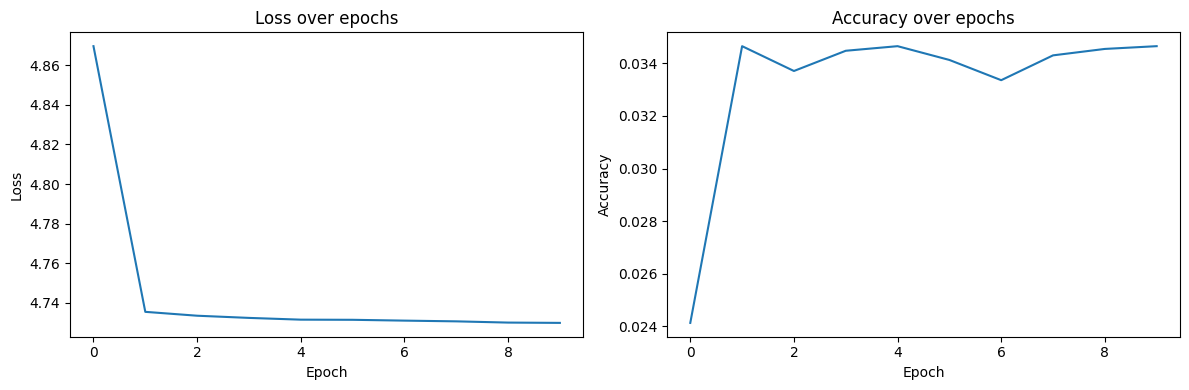

End of Training...


In [20]:
import torch.optim as optim
from torch.utils.data import DataLoader
import time

print("Training...")
def train_model(model, dataloader, optimizer, criterion, device, num_epochs=10):
    model.to(device)
    model.train()  # Set model to training mode
    
    history = {'loss': [], 'accuracy': []}
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        total = 0
        correct = 0
        epoch_start_time = time.time()
        
        for idx, batch in enumerate(dataloader):
            batch_start_time = time.time()
            
            # Move data to device with non_blocking for potential speed improvement
            inputs = batch['input_melspec'].to(device, non_blocking=True)
            labels = batch['label2id'].to(device, non_blocking=True)
            
            # Forward pass and loss calculation
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            # Track statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            batch_time = time.time() - batch_start_time
            if idx % 10 == 0:  # Print every 10 batches
                print(f'Epoch {epoch+1}, Batch {idx+1}/{len(dataloader)}, '
                      f'Time: {batch_time:.2f}s, Loss: {loss.item():.4f}')
        
        # Calculate epoch statistics
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        epoch_time = time.time() - epoch_start_time
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, '
              f'Accuracy: {epoch_acc:.4f}, Time: {epoch_time:.2f}s')
        
        # Only clear cache between epochs if needed
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    print('Training completed')
    
    # Plot loss and accuracy
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'])
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'])
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    
    plt.tight_layout()
    plt.savefig('training_history.png')  # Save the plot to a file
    plt.show()
    
    return history

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


dataloader = create_dataloader(train_file_path, primary_label_map, batch_size=512, shuffle=True, num_workers=2)


history = train_model(model, dataloader, optimizer, criterion, device, num_epochs=10)
print("End of Training...")

torch.save(model.state_dict(), 'model_weights.pth')